### ECE/CS/ISyE 524 &mdash; Introduction to Optimization &mdash; Fall 2024 ###

# Optimizing a Professional Basketball Team's Lineup #

#### Student 1 (email address), Student 2 (email address), Student 3 (email address)

*****

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Solution](#3.-Solution)
1. [Results and Discussion](#4.-Results-and-discussion)
  1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

In this project, we used real National Basketball Association (NBA) 2024 Playoff statistics from a publicly available dataset posted by Vivo Vinco on [Kaggle](https://www.kaggle.com/datasets/vivovinco/2023-2024-nba-player-stats). The goal of this project was to optimize a team’s lineup and substitutions over the course of a game to maximize team performance. Specifically, we focused on the Los Angeles Lakers, one of the most iconic franchises in basketball history, renowned for their global fanbase and decorated championship legacy. Even those who aren't avid basketball fans often recognize the Lakers, making them an engaging case study for this analysis. Success in this context was quantified using a simplified player efficiency metric that incorporates individual player contributions to points, rebounds, assists, steals, and blocks, while accounting for turnovers and missed shots.

Our team chose this project due to its practical applications and its growing importance in sports analytics. Over the last decade, data-supported decision-making has become a cornerstone of modern professional sports. From optimizing player rotations to predicting outcomes and evaluating decisions, advanced analytics is now shaping how teams compete at the highest levels. The NBA, in particular, has embraced data science through other initiatives like [a recent partnership with Sony's Hawk-Eye movement tracking systems](https://pr.nba.com/nba-sony-hawk-eye-innovations-partnership/). This reflects a broader trend in sports where traditional gut instincts are increasingly being supplemented, or even replaced by data-driven insights.

The dataset used for this project provides detailed player statistics for the 2024 playoffs. We cleaned this data by selecting only Lakers players, distinguishing between 2 positions (Guard (G) and Forward (F) for positional constraints, adding a new column with our computed efficiency metric, and only keeping the necessary columns that we used in our initial model (Player, Pos, simplified_PER). 

In our report, we first introduce the mathematical model used to define player efficiency and describe the constraints and decision variables that are implemented in the optimization problem. Next, we perform analysis through tweaking or adding various constraints to observe how these changes affect our results. Finally, we present the results of the analysis, including visualizations of optimal lineups, player contributions, and performance metrics. We conclude with a discussion of the implications of these results for the Lakers' coaching strategies and future research directions relevant to our problem.

## 2. Mathematical Model

The model we have for this question is a Mix Integer Problem. 

The decision variable we have here is a binary variable $x_{ij}$ for each $i$ (player on the team), and for each $j$ (time slot in the game, 4 minutes each so there are 12 time slots) with 1 indicate the ith player is going to play in jth time slot, and 0 indicate that this player is not going to play in jth time slot with $i \in \{ 1, 2, \cdots, 9 \}$, and $j \in \{1, 2, \cdots 12 \}$. 


Our objective in this optimization model is to maximized the overall score for our 9 players over the 12 time slot so that we can win the entire game.

We will have a score vector, denote as $E$, which indicate the efficiency (EFF) of each player, with a simple formula:
$$
E = \frac{points + rebounds + assists + steals + blocks − missed field goals − missed free throws - turnovers}{games played}
$$

#### Objective:
$$
\max_{x \in \mathbb{R}^n} \sum_{i}\sum_{j} E_i x_{ij}
$$

#### Constraint:
$$
\sum_{i} x_{ij} = 5,  \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
In each time slot, only 5 players is allowed on the court. 

$$
2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
For each time slot, there must be at least 2 and at most 3 forwards on the court at a time. 

$$
2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
For each time slot, there must be at least 2 and at most 3 forwards on the court at a time. 


$$
x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \}
$$ 
For each player, he cannot play more than 2 consecutive time slots. 


Collectively, we will have:
$$
\begin{aligned}
\underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& \sum_{i}\sum_{j} E_i x_{ij} \\
\text{subject to:}\qquad& \sum_{i} x_{ij} = 5  \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \}
\end{aligned}
$$

## 3. Implementation ##

Here, you should code up your model in Julia + JuMP and solve it. Your code should be clean, easy to read, well annotated and commented, and it should compile! You are not allowed to use other programming languages or DCP packages such as `convex.jl`. **We will be running your code, and you want to make sure that everything works if we run the code blocks in sequence**. Having multiple code blocks separated by text blocks (either as separate cells or blocks of comments) that explain the various parts of your solution will make it much easier for us to understand your project. 

We would also like to see that you make several variants or run different kinds of analysis for your problem (e.g. by changing the input parameters, the constraints or objective, or deriving a dual problem). We expect at least one-two such problem variants as part of your project.

**Remember that if you do not write your description of the project and commeent your code well, we cannot understand what you have done. Even if it is technically brilliant, you will loose points if you do not write well and comment your code well.**
It's fine to call solvers and external packages we have used in the course such as `Gurobi` or `Plots`, but try to minimize the use of other packages. We want to be able to understand what is happening in your code without looking up additional references. 

In [1]:
using JuMP, GLPK
using CSV
using DataFrames

In [2]:
# Data cleaning
nba = CSV.read("24nbaplayoffs.csv", DataFrame)
lakers = filter(row -> row.Tm == "LAL", nba)
lakers.simplified_PER = (lakers.PTS .+ lakers.TRB .+ lakers.AST .+ lakers.STL .+ lakers.BLK .- 
                         (lakers.FGA .- lakers.FG) .- (lakers.FTA .- lakers.FT) .- lakers.TOV) ./ lakers.G

lakers.Pos = [in(pos, ["PG", "SG"]) ? "G" : "F" for pos in lakers.Pos]
lakers_simple = select(lakers, :Player, :Pos, :simplified_PER)
CSV.write("lakers_stats_simple.csv", lakers_simple)

lakers = CSV.read("lakers_stats_simple.csv", DataFrame)

name = lakers[!, :Player]

# E is the efficiency data we are looking for for each player
E = lakers[!, :simplified_PER]

# P1 is a binary vector indicating if the player is a Front, with 1 indicate yes and 0 indicate no
p1 = [pos == "F" ? 1 : 0 for pos in lakers[!, :Pos]]

# P2 is a binary vector indicating if the player is a Back, with 1 indicate yes and 0 indicate no
p2 = [pos == "G" ? 1 : 0 for pos in lakers[!, :Pos]]

top_3_indices = sortperm(E, rev=true)[1:3]

3-element Vector{Int64}:
 1
 5
 7

In [3]:
# Define parameters
n_players = length(name)
n_time_slots = 12

# Create the model; since it is a mixed integer problem, we are going to use the GLPK optimizer.
model = Model(GLPK.Optimizer)

# Define decision variables.
@variable(model, x[1:n_players, 1:n_time_slots], Bin) # Binary decision variables

# Objective: Maximize the total efficiency over all time slot to win the entire game.
@objective(model, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

# Constraint 1: Each time slot must have exactly 5 players on the court.
@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)

# Constraint 2: 2 <= Number of players from position p1 <= 3 for each time slot.
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)

# Constraint 3: 2 <= Number of players from position p2 <= 3 for each time slot.
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)

# Constraint 4: No player can play more than 2 consecutive time slots.
@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)

@constraint(model, [i in top_3_indices], x[i, 1] == 1)  # Must play in the first time slot

# Solve the model
optimize!(model)

## 4. Results and discussion ##

In this section, you display and discuss the results. Show figures, plots, images, trade-off curves, or whatever else you can think of to best illustrate your results. The discussion should explain what the results mean, and how to interpret them. You should also explain the limitations of your approach/model and how sensitive your results are to the assumptions you made.

Use plots (see `PyPlot` examples from class), or you can display results in a table like this:

| Tables        | Are           | Cool  |
| ------------- |:-------------:| -----:|
| col 3 is      | right-aligned |\$1600 |
| col 2 is      | centered      |  \$12 |
| zebra stripes | are neat      |   \$1 |


## 4. Results and Analysis

The output of the model is shown below. According to our solution Anthony Davis, Spencer Dinwiddie, Rui Hachimura, Lebron James, Taurean Prince, Austin Reaves, and D'Angelo Russell play 8 time slots (32 minutes) while  Jaxson Hayes will play 4 time slots (16 minutes) and Gabe Vincent will not enter the game. This seems appropriate given our constraints, but there are multiple ways we can improve this model to make it more logical and realistic.

In [4]:
if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

Optimal solution found:
Objective value: 194.71999999999997
Player assignments:
Anthony Davis: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]
Jaxson Hayes played 4.0 time slots in total.
LeBron James: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1

Below is a visual representation of our initial subsitution pattern where blue represents a player being in the game, while green represents a player being on the bench. 

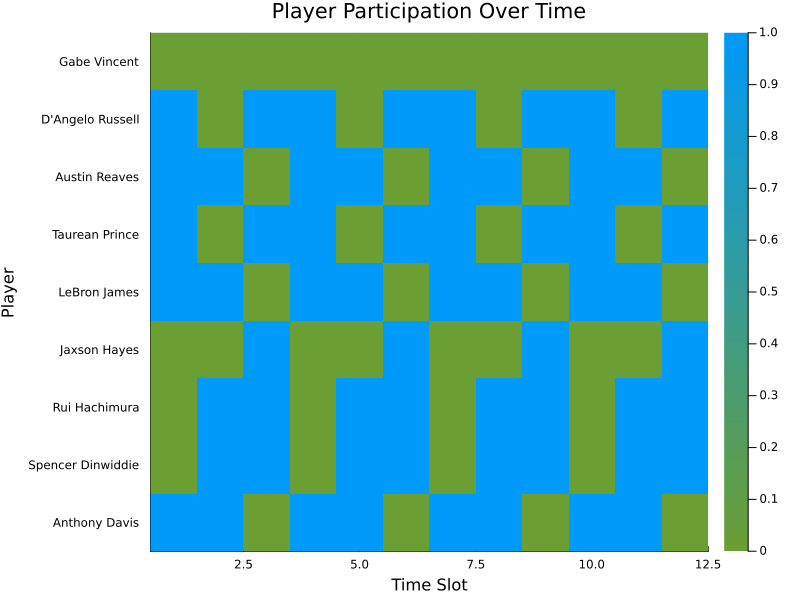

In [5]:
using Plots

time_slots = 1:12
# Create a heatmap (colored for 1, no color for 0)
heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0 "white"; 1 "black"],             # Grayscale: 1 is black, 0 is white
    xlabel = "Time Slot",      # Label for x-axis
    ylabel = "Player",         # Label for y-axis
    title = "Player Participation Over Time",
    size = (800, 600),         # Adjust plot size
    axis = :on,                 # Turn axes on for better alignment
    #framestyle = :grid
)

In [6]:
model3 = Model(GLPK.Optimizer)

min_avg_time = 0.3
max_avg_time = 0.8

# Define decision variables (continuous instead of binary)
@variable(model3, 0 <= x[1:n_players, 1:n_time_slots] <= 1)  # Proportion of time player is on court

# Objective: Maximize team efficiency
@objective(model3, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

# Constraint 1: Exactly 5 players on the court per time slot
@constraint(model3, court_constraints[j=1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)

# Constraint 2: Forwards 
@constraint(model3, forward_constraints_lower[j=1:n_time_slots], sum(p1[i] * x[i, j] for i in 1:n_players) >= 2)
@constraint(model3, forward_constraints_upper[j=1:n_time_slots], sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)

@constraint(model3, guard_constraints_lower[j=1:n_time_slots], sum(p2[i] * x[i, j] for i in 1:n_players) >= 2)
@constraint(model3, guard_constraints_upper[j=1:n_time_slots], sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)

# Lower bound: Minimum average participation
@constraint(model3, avg_participation_constraints_lower[i=1:n_players], 
    sum(x[i, j] for j in 1:n_time_slots) >= min_avg_time * n_time_slots)

# Upper bound: Maximum average participation
@constraint(model3, avg_participation_constraints_upper[i=1:n_players], 
    sum(x[i, j] for j in 1:n_time_slots) <= max_avg_time * n_time_slots)

# Solve the model
optimize!(model3)

# Check results
if termination_status(model3) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model3))
    
    x_sol = value.(x)
    for i in 1:n_players
        println("$(name[i]) plays on average: ", sum(x_sol[i, :]) / n_time_slots)
    end
else
    println("No optimal solution found.")
end

# Dual variables for court constraints (5 players per slot)
dual_court_constraints = [dual(court_constraints[j]) for j in 1:n_time_slots]
println("Dual variables for court constraints (5 players per slot): ", dual_court_constraints)

# Dual variables for forward constraints
dual_forward_constraints_lower = [dual(forward_constraints_lower[j]) for j in 1:n_time_slots]
dual_forward_constraints_upper = [dual(forward_constraints_upper[j]) for j in 1:n_time_slots]
println("Dual variables for forward constraints (lower bound): ", dual_forward_constraints_lower)
println("Dual variables for forward constraints (upper bound): ", dual_forward_constraints_upper)

# Dual variables for guard constraints
dual_guard_constraints_lower = [dual(guard_constraints_lower[j]) for j in 1:n_time_slots]
dual_guard_constraints_upper = [dual(guard_constraints_upper[j]) for j in 1:n_time_slots]
println("Dual variables for guard constraints (lower bound): ", dual_guard_constraints_lower)
println("Dual variables for guard constraints (upper bound): ", dual_guard_constraints_upper)

# Dual variables for minimum average participation
dual_avg_participation_lower = [dual(avg_participation_constraints_lower[i]) for i in 1:n_players]
println("Dual variables for minimum average participation: ", dual_avg_participation_lower)

# Dual variables for maximum average participation
dual_avg_participation_upper = [dual(avg_participation_constraints_upper[i]) for i in 1:n_players]
println("Dual variables for maximum average participation: ", dual_avg_participation_upper)

Optimal solution found:
Objective value: 217.82400000000004
Anthony Davis plays on average: 0.8000000000000002
Spencer Dinwiddie plays on average: 0.3
Rui Hachimura plays on average: 0.3
Jaxson Hayes plays on average: 0.3
LeBron James plays on average: 0.8000000000000002
Taurean Prince plays on average: 0.5999999999999996
Austin Reaves plays on average: 0.8000000000000002
D'Angelo Russell plays on average: 0.8000000000000002
Gabe Vincent plays on average: 0.3
Dual variables for court constraints (5 players per slot): [-1.48, -1.48, -1.48, -1.48, -1.48, -1.48, -1.4800000000000004, -1.48, -1.4800000000000009, -1.48, -1.4800000000000004, -1.4800000000000009]
Dual variables for forward constraints (lower bound): [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0]
Dual variables for forward constraints (upper bound): [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
Dual variables for guard constraints (lower bound): [0.0, 0.0, -0.0, -0.0, 0.0, 0.0

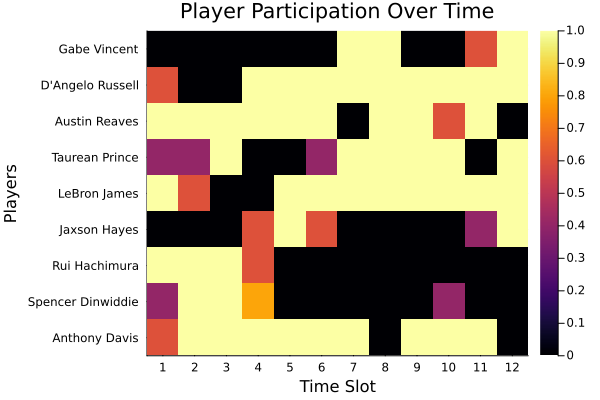

In [7]:
using Plots

# Heatmap of player participation
heatmap(x_sol, xlabel="Time Slot", ylabel="Players", title="Player Participation Over Time",
    xticks=1:n_time_slots, yticks=(1:n_players, name))

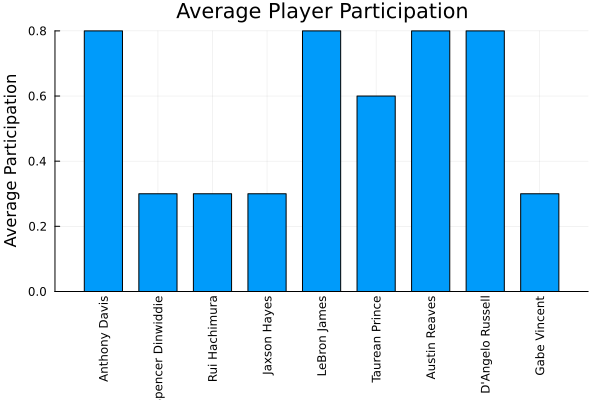

In [8]:
# Calculate average participation for each player
avg_participation = [sum(x_sol[i, :]) / n_time_slots for i in 1:n_players]

# Bar plot of average participation
bar(name, avg_participation, xlabel="Players", ylabel="Average Participation",
    title="Average Player Participation", legend=false, bar_width=0.7, xrotation=90)

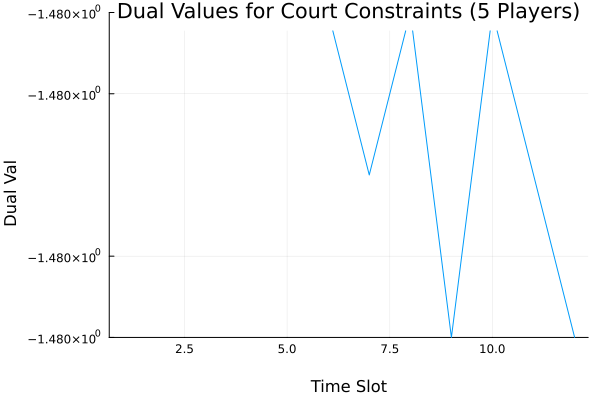

GKS: Possible loss of precision in routine SET_WINDOW


In [9]:
# Line plot of shadow prices for court constraints
plot(1:n_time_slots, dual_court_constraints, xlabel="Time Slot", ylabel="Dual Val",
    title="Dual Values for Court Constraints (5 Players)", legend=false)

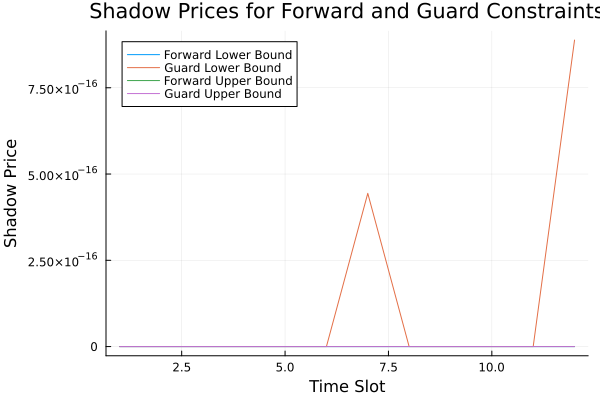

In [10]:
# Plot lower bounds
plot(1:n_time_slots, dual_forward_constraints_lower, label="Forward Lower Bound", xlabel="Time Slot", ylabel="Shadow Price",
    title="Shadow Prices for Forward and Guard Constraints")
plot!(1:n_time_slots, dual_guard_constraints_lower, label="Guard Lower Bound")

# Plot upper bounds
plot!(1:n_time_slots, dual_forward_constraints_upper, label="Forward Upper Bound")
plot!(1:n_time_slots, dual_guard_constraints_upper, label="Guard Upper Bound")

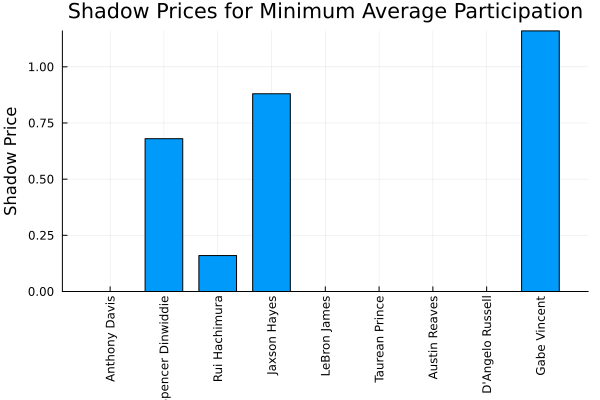

In [11]:
# Bar plot for minimum average participation shadow prices
bar(name, dual_avg_participation_lower, xlabel="Players", ylabel="Shadow Price",
    title="Shadow Prices for Minimum Average Participation", legend=false, bar_width=0.7, xrotation=90)

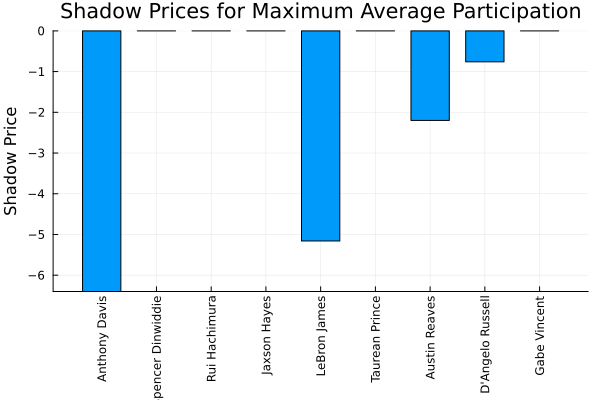

In [16]:
# Bar plot for maximum average participation shadow prices
bar(name, dual_avg_participation_upper, xlabel="Players", ylabel="Shadow Price",
    title="Shadow Prices for Maximum Average Participation", legend=false, bar_width=0.7, xrotation=90)

In [13]:
# each player have least 2 and most times 8 appear

In [14]:
# 1 <= player <= 4 for the back and front

In [15]:
# use value between 0 and 1....

## 5. Conclusion ##

Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project.

## 6. Author Contributions

Note: The contributions in each category must sum to 100%. See Canvas for more details on what type of work belongs in each category.

#### 1. Modelling  
Student A: Percentage contribution %  
Student B: Percentage contribution %  
Student C: Percentage contribution %  

  
#### 2. Analysis  
Student A: Percentage contribution %  
Student B: Percentage contribution %  
Student C: Percentage contribution %  


#### 3. Data Gathering  
Student A: Percentage contribution %  
Student B: Percentage contribution %  
Student C: Percentage contribution %  


#### 4. Software Implementation  
Student A: Percentage contribution %  
Student B: Percentage contribution %  
Student C: Percentage contribution %  


#### 5. Report Writing    
Student A: Percentage contribution %  
Student B: Percentage contribution %  
Student C: Percentage contribution %  